<a href="https://colab.research.google.com/github/timmao78/git_demo/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [118]:
#Create a Model Class that inherits nn.Module
class Model(nn.Module):
  # Input layer(4 feature of the flower) -- >
  # Hidden layer1(number of neurons) -->
  # H2(n) -->
  # output(3 classes of iris)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [119]:
#pick a manual seed for radomization
torch.manual_seed(41)
model = Model()

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [121]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [122]:
my_df['species'] = my_df['species'].replace('setosa',0.0)
my_df['species'] = my_df['species'].replace('versicolor',1.0)
my_df['species'] = my_df['species'].replace('virginica',2.0)
my_df

/tmp/ipykernel_1916/3775887882.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [123]:
# Train Test Split
X = my_df.drop('species', axis=1)
y = my_df['species']

In [124]:
X = X.values
y = y.values

In [125]:
from sklearn.model_selection import train_test_split

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=41)

In [127]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [128]:
# Set the criteria of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = larning rate(if error doesn't go down after a bunch of iterations(epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [129]:
#Train our model
#Epochs?(one run thru all the training data in our network)
epochs = 10000
losses=[]
losses2=[]

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) #Get predicted result
  y_pred2 = model.forward(X_test)

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train)
  loss2 = criterion(y_pred2, y_test)

 # Keep Track of our losses
  losses.append(loss.detach().numpy())
  losses2.append(loss2.detach().numpy())

  # print every 10 epoch
  if i%10 == 0:
    print(f"Epoch:{i} and loss: {loss} {loss2}")

  # Do some back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch:0 and loss: 1.1251550912857056 1.1192831993103027
Epoch:10 and loss: 1.0096259117126465 1.0119010210037231
Epoch:20 and loss: 0.8157405853271484 0.837968647480011
Epoch:30 and loss: 0.585706353187561 0.6245946288108826
Epoch:40 and loss: 0.3999636471271515 0.446165531873703
Epoch:50 and loss: 0.26768800616264343 0.31673768162727356
Epoch:60 and loss: 0.17942361533641815 0.2339940220117569
Epoch:70 and loss: 0.12151690572500229 0.1807546466588974
Epoch:80 and loss: 0.0860118493437767 0.1512281745672226
Epoch:90 and loss: 0.06520850956439972 0.13731469213962555
Epoch:100 and loss: 0.05286576226353645 0.13151279091835022
Epoch:110 and loss: 0.04508381709456444 0.12955720722675323
Epoch:120 and loss: 0.03979949280619621 0.12961629033088684
Epoch:130 and loss: 0.035970740020275116 0.1306859403848648
Epoch:140 and loss: 0.03293721750378609 0.13198398053646088
Epoch:150 and loss: 0.03041938506066799 0.13316796720027924
Epoch:160 and loss: 0.026795217767357826 0.13814420998096466
Epoch:1

Text(0.5, 0, 'epoch')

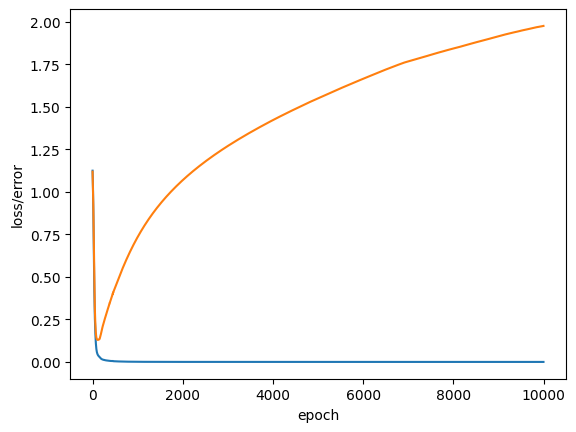

In [130]:
# Graph it out
plt.plot(range(epochs), losses)
plt.plot(range(epochs), losses2)
plt.ylabel("loss/error")
plt.xlabel('epoch')